# YOLO-pose

In [2]:
import cv2
from ultralytics import YOLO
import random
import numpy as np
import matplotlib.pyplot as plt

## Custom model test:

In [3]:
list_point_names = ["nose","tail", "front_left_wheel", "front_right_wheel", "back_left_wheel", "back_right_wheel"]
len(list_point_names)

6


0: 384x640 1 skateboard, 83.8ms
Speed: 8.4ms preprocess, 83.8ms inference, 22.1ms postprocess per image at shape (1, 3, 384, 640)


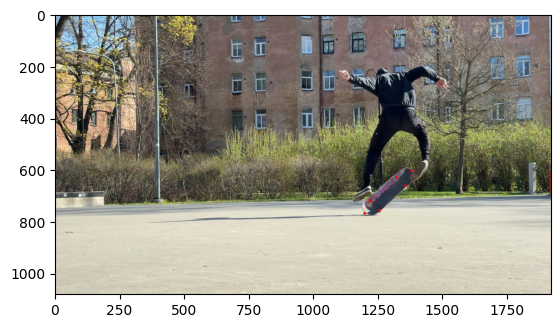

In [6]:
model = YOLO('models/skate-pose-2.0.pt')  # load a trained model
image = cv2.imread('test/images/kickflip.jpg') # Replace image with existing
results = model.predict(image, iou=0.4, conf=0.5)

for i in range(len(results[0].keypoints.xy)):
    keypoints = results[0].keypoints.xy[i]
    for j, point in enumerate(keypoints):
        x, y = point
        if x > 0 and y > 0:
            cv2.circle(image, (int(x), int(y)), 5, (0,0,255), -1)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
plt.imshow(image);

In [7]:
point_pairs = [
    (0, 1), # nose tail
    (2, 3), # left front wheel - right front wheel
    (4, 5), # left back wheel - right back wheel
]

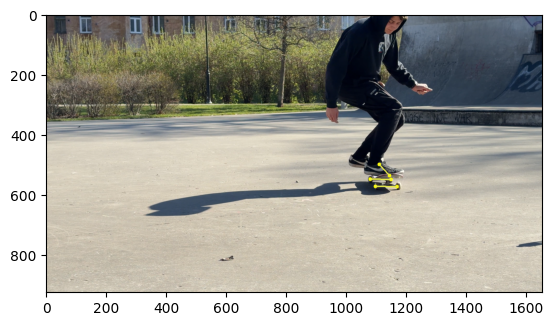

In [8]:
import cv2
import matplotlib.pyplot as plt

model = YOLO("models/skate-pose-2.0.pt")  # load a trained model
image = cv2.imread("test/images/fs-180.png")  # Replace image with existing
results = model.predict(image, iou=0.4, conf=0.5, verbose=False)


for i in range(len(results[0].keypoints.xy)):
    keypoints = results[0].keypoints.xy[i]

    random.seed(int(i+100))
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

    # Draw points
    for j, point in enumerate(keypoints):
        x, y = point
        if x > 0 and y > 0:  # Check that coordinates are greater than zero
            cv2.circle(image, (int(x), int(y)), 6, (0, 255, 255), -1)

    # Connect points with lines
    for pair in point_pairs:
        start, end = pair
        if keypoints[start][0] > 0 and keypoints[start][1] > 0 and keypoints[end][0] > 0 and keypoints[end][1] > 0:  # Check that both pairs of coordinates are greater than zero
            x1, y1 = int(keypoints[start][0]), int(keypoints[start][1])
            x2, y2 = int(keypoints[end][0]), int(keypoints[end][1])
            cv2.line(image, (x1, y1), (x2, y2), color, 3)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 
plt.imshow(image)  # Display image with points and lines
plt.show()

In [9]:
results[0].keypoints

ultralytics.engine.results.Keypoints object with attributes:

conf: tensor([[0.9996, 0.9999, 0.9998, 0.9999, 1.0000, 0.9999]], device='cuda:0')
data: tensor([[[1.1453e+03, 5.3717e+02, 9.9958e-01],
         [1.1112e+03, 5.0089e+02, 9.9986e-01],
         [1.1708e+03, 5.7468e+02, 9.9985e-01],
         [1.0988e+03, 5.7388e+02, 9.9990e-01],
         [1.1507e+03, 5.5025e+02, 9.9996e-01],
         [1.0816e+03, 5.4970e+02, 9.9995e-01]]], device='cuda:0')
has_visible: True
orig_shape: (925, 1654)
shape: torch.Size([1, 6, 3])
xy: tensor([[[1145.2554,  537.1693],
         [1111.1747,  500.8864],
         [1170.7617,  574.6763],
         [1098.7516,  573.8825],
         [1150.7217,  550.2491],
         [1081.5736,  549.6957]]], device='cuda:0')
xyn: tensor([[[0.6924, 0.5807],
         [0.6718, 0.5415],
         [0.7078, 0.6213],
         [0.6643, 0.6204],
         [0.6957, 0.5949],
         [0.6539, 0.5943]]], device='cuda:0')

# Video

In [10]:
KEYPOINT_NAMES = [
    "end A",
    "end B",
    "wheel A left",
    "wheel A right",
    "wheel B left",
    "wheel B right",
]

COLORS = [
    (0, 0, 255), # Red
    (255, 0, 255), # Magenta
    (255, 255, 0), # Yellow
    (150, 255, 150), # Green
    (255, 0, 0), # Blue
    (0, 255, 0), # Lime
]

In [11]:
model = YOLO("models/skate-pose-2.0.pt")

input_video = "test/clips/flat-1/flat-3.mp4"
output_video = "test/clips/predictions/flat-3_predicted.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (width, height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(
        frame,
        iou=0.4,
        conf=0.5,
        verbose=False
    )

    if results[0].keypoints is not None:
        for i in range(len(results[0].keypoints.xy)):
            keypoints = results[0].keypoints.xy[i]

            for j, point in enumerate(keypoints):
                x, y = point
                if x > 0 and y > 0:
                    x, y = int(x), int(y)

                    color = COLORS[j]
                    label = KEYPOINT_NAMES[j]

                    cv2.circle(frame, (x, y), 6, color, -1)

                    cv2.putText(
                        frame,
                        label,
                        (x + 8, y - 8),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        color,
                        2,
                        cv2.LINE_AA
                    )

            for pair in point_pairs:
                start, end = pair

                if (
                    keypoints[start][0] > 0 and keypoints[start][1] > 0 and
                    keypoints[end][0] > 0 and keypoints[end][1] > 0
                ):
                    x1, y1 = int(keypoints[start][0]), int(keypoints[start][1])
                    x2, y2 = int(keypoints[end][0]), int(keypoints[end][1])

                    cv2.line(frame, (x1, y1), (x2, y2), (0, 255, 255), 3)

    out.write(frame)

cap.release()
out.release()

print(f"Saved annotated video to: {output_video}")

Saved annotated video to: test/clips/predictions/flat-3_predicted.mp4
